# PayGuard — AI-Powered Payment Fraud Detection

## Notebook 02: Data Preprocessing and Class Imbalance Handling

This notebook prepares the Kaggle Credit Card Fraud Detection dataset for machine learning.

The main goals are:

- Load the raw transaction data from `data/raw/creditcard.csv`
- Check data quality issues such as null values, duplicates, and data types
- Scale the `Amount` and `Time` features using `StandardScaler`
- Split the dataset into training and testing sets using stratified sampling
- Apply SMOTE only to the training set to handle class imbalance
- Save processed datasets and the fitted scaler for future model training

> Important: SMOTE is applied only after the train/test split.  
> This prevents synthetic samples from leaking information into the test set.

## 1. Setup

We import all required libraries, define project paths, and configure display settings.

In [1]:
from pathlib import Path
from typing import List, Tuple

import joblib
import numpy as np
import pandas as pd
import plotly.express as px
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.4f}".format)

RANDOM_STATE = 42
TEST_SIZE = 0.20

PROJECT_ROOT = Path.cwd()

possible_roots: List[Path] = [
    PROJECT_ROOT,
    PROJECT_ROOT.parent,
]

DATA_PATH = None
for root in possible_roots:
    candidate = root / "data" / "raw" / "creditcard.csv"
    if candidate.exists():
        DATA_PATH = candidate
        PROJECT_ROOT = root
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        "Could not find data/raw/creditcard.csv. "
        "Please place creditcard.csv inside the data/raw/ folder."
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {DATA_PATH}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Models directory: {MODELS_DIR}")

Project root: C:\Users\This PC\Downloads\payguard
Raw data path: C:\Users\This PC\Downloads\payguard\data\raw\creditcard.csv
Processed data directory: C:\Users\This PC\Downloads\payguard\data\processed
Models directory: C:\Users\This PC\Downloads\payguard\models


## 2. Load Raw Data

We load the raw Kaggle credit card fraud dataset and inspect the initial shape.

In [2]:
df = pd.read_csv(DATA_PATH)

print(f"Raw dataset shape: {df.shape[0]:,} rows and {df.shape[1]:,} columns")
display(df.head())

Raw dataset shape: 284,807 rows and 31 columns


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0
3,1.0000,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,123.5000,0
4,2.0000,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,69.9900,0


## 3. Exploratory Data Quality Checks

Before feature engineering, we check for missing values, duplicate rows, data types, and target class distribution.

In [3]:
print("Data types:")
display(df.dtypes.to_frame(name="dtype"))

print("\nDataset info:")
df.info()

Data types:


,dtype
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64



Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21   

In [4]:
null_summary = (
    df.isnull()
    .sum()
    .reset_index()
    .rename(columns={"index": "column", 0: "missing_values"})
)

null_summary["missing_percentage"] = (
    null_summary["missing_values"] / len(df) * 100
).round(4)

display(null_summary.sort_values("missing_values", ascending=False))

duplicate_count = df.duplicated().sum()
duplicate_percentage = duplicate_count / len(df) * 100

print(f"Duplicate rows found: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_percentage:.4f}%")

,column,missing_values,missing_percentage
0,Time,0,0.0000
1,V1,0,0.0000
2,V2,0,0.0000
3,V3,0,0.0000
4,V4,0,0.0000
5,V5,0,0.0000
6,V6,0,0.0000
7,V7,0,0.0000
8,V8,0,0.0000
9,V9,0,0.0000


Duplicate rows found: 1,081
Duplicate percentage: 0.3796%


In [5]:
class_distribution = (
    df["Class"]
    .value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .reset_index()
)

class_distribution.columns = ["transaction_type", "count"]
class_distribution["percentage"] = (
    class_distribution["count"] / len(df) * 100
).round(4)

display(class_distribution)

,transaction_type,count,percentage
0,Legitimate,284315,99.8273
1,Fraud,492,0.1727


## 4. Clean Data

We remove duplicate records and validate that the target column exists.

For missing values, this dataset usually has no nulls.  
If null values are present, rows with missing values are removed to keep the preprocessing simple and reliable.

In [6]:
required_columns = {"Time", "Amount", "Class"}
missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

before_cleaning_shape = df.shape

df_clean = df.drop_duplicates().dropna().reset_index(drop=True)

after_cleaning_shape = df_clean.shape

print(f"Shape before cleaning: {before_cleaning_shape}")
print(f"Shape after cleaning: {after_cleaning_shape}")
print(f"Rows removed: {before_cleaning_shape[0] - after_cleaning_shape[0]:,}")

Shape before cleaning: (284807, 31)
Shape after cleaning: (283726, 31)
Rows removed: 1,081


## 5. Feature Engineering

The `Amount` and `Time` columns are not PCA-transformed, unlike `V1` to `V28`.

We standardize them using `StandardScaler` and create:

- `Amount_Scaled`
- `Time_Scaled`

Then we drop the original `Amount` and `Time` columns.

In [7]:
feature_df = df_clean.copy()

scaler = StandardScaler()

feature_df[["Amount_Scaled", "Time_Scaled"]] = scaler.fit_transform(
    feature_df[["Amount", "Time"]]
)

feature_df = feature_df.drop(columns=["Amount", "Time"])

print(f"Feature-engineered dataset shape: {feature_df.shape}")
display(feature_df.head())

Feature-engineered dataset shape: (283726, 31)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Scaled,Time_Scaled
0,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,0.0908,-0.5516,-0.6178,-0.9914,-0.3112,1.4682,-0.4704,0.2080,0.0258,0.4040,0.2514,-0.0183,0.2778,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,0,0.2442,-1.9968
1,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,-0.1670,1.6127,1.0652,0.4891,-0.1438,0.6356,0.4639,-0.1148,-0.1834,-0.1458,-0.0691,-0.2258,-0.6387,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,0,-0.3426,-1.9968
2,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,0.2076,0.6245,0.0661,0.7173,-0.1659,2.3459,-2.8901,1.1100,-0.1214,-2.2619,0.5250,0.2480,0.7717,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,0,1.1589,-1.9968
3,-0.9663,-0.1852,1.7930,-0.8633,-0.0103,1.2472,0.2376,0.3774,-1.3870,-0.0550,-0.2265,0.1782,0.5078,-0.2879,-0.6314,-1.0596,-0.6841,1.9658,-1.2326,-0.2080,-0.1083,0.0053,-0.1903,-1.1756,0.6474,-0.2219,0.0627,0.0615,0,0.1399,-1.9968
4,-1.1582,0.8777,1.5487,0.4030,-0.4072,0.0959,0.5929,-0.2705,0.8177,0.7531,-0.8228,0.5382,1.3459,-1.1197,0.1751,-0.4514,-0.2370,-0.0382,0.8035,0.4085,-0.0094,0.7983,-0.1375,0.1413,-0.2060,0.5023,0.2194,0.2152,0,-0.0738,-1.9968


## 6. Train/Test Split

We split the dataset into training and testing sets using an 80/20 split.

Because fraud is rare, we use `stratify=y` to preserve the class ratio in both training and testing datasets.

In [8]:
X = feature_df.drop(columns=["Class"])
y = feature_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train shape: (226980,)
y_test shape: (56746,)


## 7. Class Distribution Before SMOTE

Before applying SMOTE, we check the training set class distribution.

,transaction_type,count,percentage
0,Legitimate,226602,99.8335
1,Fraud,378,0.1665


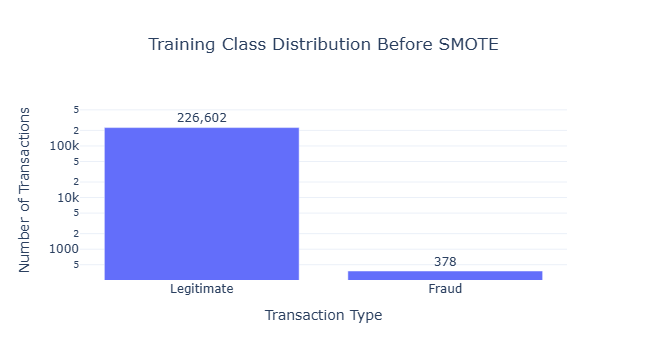

In [9]:
before_smote = (
    y_train.value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .reset_index()
)

before_smote.columns = ["transaction_type", "count"]
before_smote["percentage"] = (
    before_smote["count"] / before_smote["count"].sum() * 100
).round(4)

display(before_smote)

fig = px.bar(
    before_smote,
    x="transaction_type",
    y="count",
    text="count",
    title="Training Class Distribution Before SMOTE",
    labels={
        "transaction_type": "Transaction Type",
        "count": "Number of Transactions",
    },
)

fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(template="plotly_white", title_x=0.5, yaxis_type="log")
fig.show()

## 8. Handle Class Imbalance Using SMOTE

SMOTE creates synthetic fraud samples in the training set only.

This helps the model learn minority-class fraud patterns without changing the untouched test set.

In [10]:
smote = SMOTE(random_state=RANDOM_STATE)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Original training shape: {X_train.shape}")
print(f"Resampled training shape: {X_train_resampled.shape}")

Original training shape: (226980, 30)
Resampled training shape: (453204, 30)


## 9. Class Distribution After SMOTE

After SMOTE, the training set should have a balanced distribution between legitimate and fraud transactions.

,transaction_type,count,percentage
0,Legitimate,226602,50.0000
1,Fraud,226602,50.0000


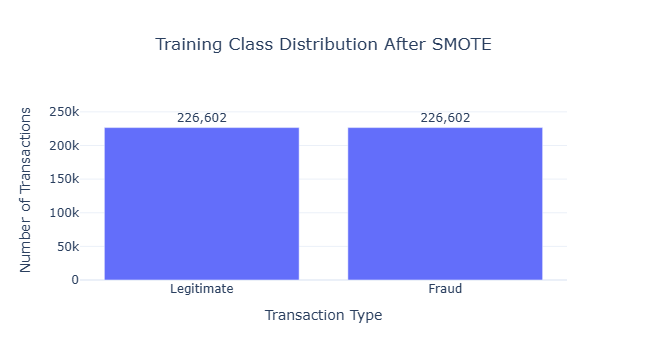

In [11]:
after_smote = (
    pd.Series(y_train_resampled, name="Class")
    .value_counts()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .reset_index()
)

after_smote.columns = ["transaction_type", "count"]
after_smote["percentage"] = (
    after_smote["count"] / after_smote["count"].sum() * 100
).round(4)

display(after_smote)

fig = px.bar(
    after_smote,
    x="transaction_type",
    y="count",
    text="count",
    title="Training Class Distribution After SMOTE",
    labels={
        "transaction_type": "Transaction Type",
        "count": "Number of Transactions",
    },
)

fig.update_traces(texttemplate="%{text:,}", textposition="outside")
fig.update_layout(template="plotly_white", title_x=0.5)
fig.show()

## 10. Save Processed Data and Fitted Scaler

We save the processed splits as `.pkl` files in `data/processed/`.

Saved files:

- `X_train.pkl`
- `X_test.pkl`
- `y_train.pkl`
- `y_test.pkl`
- `scaler.pkl`

`X_train.pkl` and `y_train.pkl` contain the SMOTE-resampled training data.  
`X_test.pkl` and `y_test.pkl` remain untouched for fair model evaluation.

In [12]:
joblib.dump(X_train_resampled, PROCESSED_DIR / "X_train.pkl")
joblib.dump(X_test, PROCESSED_DIR / "X_test.pkl")
joblib.dump(y_train_resampled, PROCESSED_DIR / "y_train.pkl")
joblib.dump(y_test, PROCESSED_DIR / "y_test.pkl")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

print("Processed data saved successfully:")
print(f"- {PROCESSED_DIR / 'X_train.pkl'}")
print(f"- {PROCESSED_DIR / 'X_test.pkl'}")
print(f"- {PROCESSED_DIR / 'y_train.pkl'}")
print(f"- {PROCESSED_DIR / 'y_test.pkl'}")
print(f"- {MODELS_DIR / 'scaler.pkl'}")

Processed data saved successfully:
- C:\Users\This PC\Downloads\payguard\data\processed\X_train.pkl
- C:\Users\This PC\Downloads\payguard\data\processed\X_test.pkl
- C:\Users\This PC\Downloads\payguard\data\processed\y_train.pkl
- C:\Users\This PC\Downloads\payguard\data\processed\y_test.pkl
- C:\Users\This PC\Downloads\payguard\models\scaler.pkl


## 11. Preprocessing Summary

The PayGuard dataset is now ready for model training.

Key completed steps:

- Raw data loaded from `data/raw/creditcard.csv`
- Missing values and duplicate rows handled
- `Amount` and `Time` standardized using `StandardScaler`
- Original `Amount` and `Time` columns removed
- Train/test split completed with stratification
- SMOTE applied only to the training data
- Processed datasets and scaler saved for the modeling pipeline